# CNN architecture testing

In this notebook different CNN model architectures are tested and compared. Starting from simple onelayer CNN's to deeper ones. While testing each model hyperparameter tuning is performed. There for a goal is to use monitoriung tool to analyse the tuning process and finding good models.

### Selection of the monitoring tool

Monitoring tools are important for efficient model creation. Core concept for developing a model is keeping track of training vs. validation behaviour over time. A monitoring tool makes this process more efficient and reliable. It can display loss and accuracy curves, weights and gradients, this helps detecting over- and underfitting, as well as bad learning rates. It speedas up the Hyperparameter tuning process, because it systematically tracks experiments and makes easy comparing possible. Over all, it helps to keep an overview over experiments and model testing, thus enables finding good models faster.\
\
There are multiple different solutions for monitoring tools. We have looked at three of them:
- TensorBoard
- Weights & Biases (W&B)
- MLFlow



In [1]:
'''Overview table'''
#| Feature               | TensorBoard       | Weights & Biases (W&B) | MLflow                   |
#| --------------------- | ----------------- | ---------------------- | ------------------------ |
#| Setup                 | Very easy (local) | Easy (cloud login)     | Medium (needs setup)     |
#| UI                    | Basic but solid   | Best-in-class          | Functional               |
#| Experiment tracking   | Limited           | Excellent              | Excellent                |
#| Hyperparameter sweeps | Manual            | Built-in, strong       | Possible but less smooth |
#| Collaboration         | Weak              | Strong (cloud)         | Medium                   |
#| Offline usage         | Yes               | Limited (sync later)   | Yes                      |
#| Framework integration | Native PyTorch/TF | Works with everything  | General ML               |
#| MLOps pipeline        | Weak              | Medium                 | Strong                   |


'Overview table'

Looking at the overview table, we decided we want to try Weights & Biases. Because it versitile, easy setup and has the possibility for hyperparmeter sweeps. Disadvantage is that the programm doesn't work locally or offline.

## importing and setting up

In [21]:
# Imports
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt
import os

In [6]:
# Check for GPU
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else: 
    device = torch.device("cpu")

print(device)

cuda


## Loading and preparing the data (sanity check)

### Checking class distribution of the images

In [16]:
# count number of images in each class of the training dataset
data_dir = '../data/icosimal_img_class_03/train'

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])
        class_counts[class_name] = count

# print nicely
for cls, count in sorted(class_counts.items()):
    print(f"{cls}: {count}")

cat: 2400
chicken: 2400
cow: 2400
dog: 2400
elephant: 2400
horse: 2400
rabbit: 2400
sheep: 2400
squirrel: 2400
zebra: 2400


In [17]:
# count number of images in each class of the validation dataset
data_dir = '../data/icosimal_img_class_03/validate'

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])
        class_counts[class_name] = count

# print nicely
for cls, count in sorted(class_counts.items()):
    print(f"{cls}: {count}")

cat: 600
chicken: 600
cow: 600
dog: 600
elephant: 600
horse: 600
rabbit: 600
sheep: 600
squirrel: 600
zebra: 600


All calsses are evenly balanced.

### Loading the data

In [ ]:
# define image size
# Original image size 224x224, can be changed to 128x128 or 64x64 for faster training but may reduce accuracy
size = 224

# Transformer to ensure all images are the same size and converted to tensors
transformer = transforms.Compose([
    transforms.Resize((size, size)), # transform to desired size
    transforms.ToTensor(), # transforms into tensor
    transforms.
])

# load training and validation dataset
train_dataset = datasets.ImageFolder(root='../data/icosimal_img_class_03/train', transform=transformer)
val_dataset = datasets.ImageFolder(root='../data/icosimal_img_class_03/validate', transform=transformer)

In [12]:
# check dataset sizes
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Training dataset size: 24000
Validation dataset size: 6000


Don't we need a test dataset?\
\
Suggestion: Splitting training set into training and test set for final model evaluation.
- Trainingset size: 20000 ~66%
- Validationset size: 6000 ~20%
- Testset size: 4000 ~13%

In [13]:
train_dataset, test_dataset = torch.utils.data.random_split(train_dataset, [len(train_dataset) - 4000, 4000]) 

In [14]:
# check dataset sizes
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 20000
Validation dataset size: 6000
Test dataset size: 4000


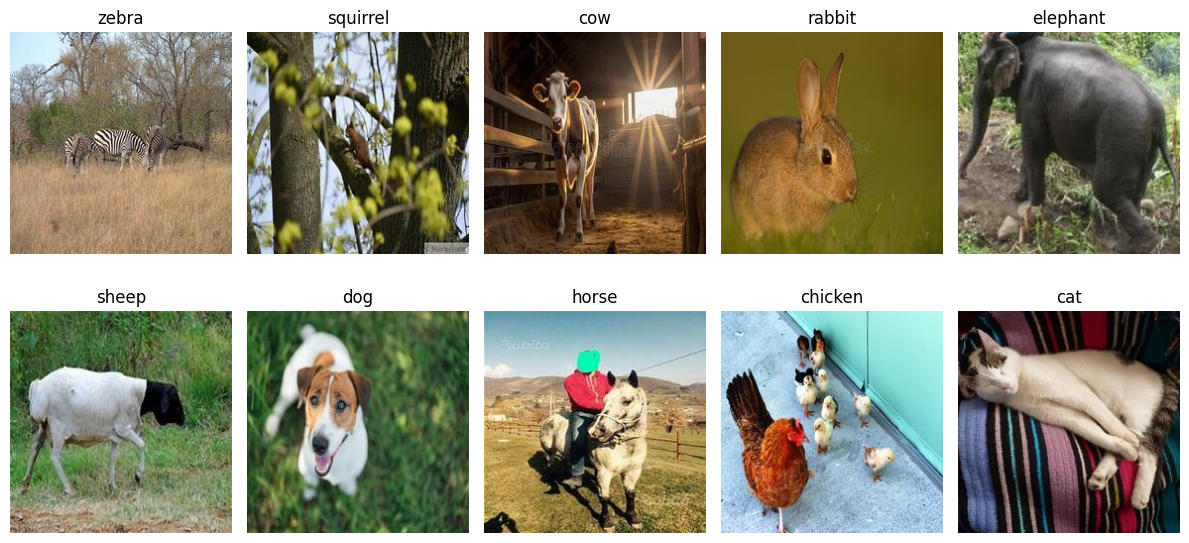

In [ ]:
# print one image per class from the test dataset
dataset = test_dataset.dataset

class_names = dataset.classes

# store first image per class
seen = {}

for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    
    if label not in seen:
        seen[label] = img
    
    if len(seen) == len(class_names):
        break

# plot
plt.figure(figsize=(12, 6))

for idx, (label, img) in enumerate(seen.items()):
    plt.subplot(2, 5, idx + 1)   # 10 classes → 2x5 grid
    
    # handle tensor vs PIL
    if hasattr(img, "permute"):
        img = img.permute(1, 2, 0)
    
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Nornmalizing the images 